# Interplanetary Mission Design: Lambert Targeting, Porkchop Optimisation and Launch Vehicle Sizing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mukid1805/NewtonianPropagator/blob/main/notebooks/01_interplanetary_mission_design.ipynb)
[![nbviewer](https://img.shields.io/badge/Render-nbviewer-orange?style=flat&logo=jupyter)](https://nbviewer.org/github/mukid1805/NewtonianPropagator/blob/main/notebooks/01_interplanetary_mission_design.ipynb)
[![GitHub Source](https://img.shields.io/badge/GitHub-Repository-181717?style=flat&logo=github)](https://github.com/mukid1805/NewtonianPropagator)
[![Python 3.10+](https://img.shields.io/badge/Python-3.10%2B-blue?style=flat&logo=python&logoColor=white)](https://www.python.org/)

---

### Abstract & Scope
This investigation delineates an end-to-end preliminary trajectory design pipeline for an Earth-to-Mars interplanetary transfer utilizing the `NewtonianPropagator` astrodynamical architecture:

1. **Planetary Ephemerides:** Extraction of heliocentric Cartesian state vectors ($\mathbf{r}, \mathbf{v}$) over the 2026 synodic launch opportunity via the Standish secular ephemeris model.
2. **Two-Point Boundary Value Problem (TPBVP):** Universal-variable resolution of Lambert's problem across a discrete departure-arrival epoch lattice.
3. **Porkchop Contour Synthesis:** Parametric mapping of characteristic injection energy ($C_3$) alongside hyperbolic arrival excess speed ($v_\infty$).
4. **Launch Vehicle Performance Coupling:** Sizing and injected payload mass evaluation via empirical launcher polynomials (`payload_for_c3`).
5. **Numerical Trajectory Propagation:** High-fidelity orbital integration using the embedded Dormand-Prince adaptive Runge-Kutta (RK45) scheme.

#### Engineering Fidelity & Model Assumptions
The analytical results generated in this study correspond to **Phase-A preliminary mission design and architecture trade formulation**. Key dynamical assumptions include:
* **Gravitational Field:** Central-body heliocentric point-mass dynamics ($\mu_\odot$). Third-body gravitational perturbations (e.g., Jupiter, the Earth–Moon barycentre), solar radiation pressure (SRP), and general relativistic corrections are excluded from this preliminary baseline.
* **Patched-Conics Formulation:** Zero-radius sphere-of-influence (SOI) boundaries are assumed for departure and arrival targeting. The characteristic energy $C_3$ and arrival hyperbolic excess speed $v_{\infty,\text{arr}}$ provide boundary conditions for planetary escape and capture hyperbolae.
* **Ephemeris Resolution:** Planetary states are resolved via analytical mean orbital element expansions accurate to within first-order secular variations. For operational deep-space navigation (Phase C/D), these analytical vectors are routinely substituted with numerical ephemerides (e.g., NASA JPL DE440 SPICE kernels) augmented with trajectory correction manoeuvre ($\Delta v_{\text{TCM}}$) allocations.

In [22]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# 1. Check if running in Google Colab
if 'google.colab' in sys.modules:
    # Clone the repository if it hasn't been cloned yet
    if not os.path.exists('NewtonianPropagator'):
        !git clone https://github.com/mukid1805/NewtonianPropagator.git

    # Add the cloned directory to the path
    repo_path = os.path.abspath('NewtonianPropagator')
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

# 2. Otherwise, handle standard local Jupyter path resolution
else:
    current_dir = os.getcwd()
    if 'notebooks' in current_dir:
        root_dir = os.path.abspath(os.path.join(current_dir, '..'))
    else:
        root_dir = os.path.abspath('.')

    if root_dir not in sys.path:
        sys.path.insert(0, root_dir)

import core
from core.time import date_to_mjd2000, SECS_PER_DAY
from core.constants import AU
from core.ephemeris import get_planet_state, MU_SUN
from core.lambert import solve_lambert
from core.launchers import list_available_launchers, get_launcher
from core.integrators import rk45_adaptive

print(f"Initialised NewtonianPropagator v{getattr(core, '__version__', '1.0.0')}")

available_vehicles = list_available_launchers()
print(f"Catalogued Launch Vehicles ({len(available_vehicles)} operational configurations):")
for vehicle in available_vehicles:
    print(f"  * {vehicle['name']:<55} | Operator: {vehicle['operator']:<12} | Status: {vehicle['status']}")

Initialised NewtonianPropagator v1.0.1.dev1+gfa2b9daa4
Catalogued Launch Vehicles (12 operational configurations):
  * LVM3 / GSLV Mk III (Chandrayaan / Gaganyaan)            | Operator: ISRO         | Status: active
  * PSLV-XL (MOM / Chandrayaan-1 / Aditya-L1)               | Operator: ISRO         | Status: active
  * GSLV Mk II (CUS / NISAR)                                | Operator: ISRO         | Status: active
  * SSLV (Small Satellite Launch Vehicle)                   | Operator: ISRO         | Status: active
  * Falcon 9 (Drone Ship ASDS Recovery)                     | Operator: SpaceX       | Status: active
  * Falcon 9 (Fully Expendable)                             | Operator: SpaceX       | Status: active
  * Falcon Heavy (Fully Expendable)                         | Operator: SpaceX       | Status: active
  * Electron (Kick Stage / Curie)                           | Operator: Rocket Lab   | Status: active
  * Atlas V 551 (Centaur)                                   | Operato

---

## 1. Temporal Boundary Discretisation

The Earth-Mars synodic geometry in late 2026 provides a viable minimum-energy ballistic transfer opportunity. We discretise the calendar search space over the following temporal boundaries:

* **Departure Window ($\mathcal{W}_{\text{dep}}$):** 1 October 2026 to 1 December 2026
* **Arrival Window ($\mathcal{W}_{\text{arr}}$):** 1 June 2027 to 1 December 2027

To preserve compatibility with the epoch formulation in `core.time`, temporal instances are initialised as explicit `datetime.datetime` structures prior to conversion into Modified Julian Date 2000 (MJD2000) scalars:

$$\text{MJD2000} = \text{JD} - 2451545.0$$

In [23]:
# Define temporal boundaries with explicit datetime instances
dep_start = datetime.datetime(2026, 10, 1, 0, 0, 0)
dep_end = datetime.datetime(2026, 12, 1, 0, 0, 0)
arr_start = datetime.datetime(2027, 6, 1, 0, 0, 0)
arr_end = datetime.datetime(2027, 12, 1, 0, 0, 0)

temporal_step_days = 2

departure_dates = [
    dep_start + datetime.timedelta(days=i)
    for i in range(0, (dep_end - dep_start).days, temporal_step_days)
]
arrival_dates = [
    arr_start + datetime.timedelta(days=i)
    for i in range(0, (arr_end - arr_start).days, temporal_step_days)
]

mjd_dep_array = np.array([date_to_mjd2000(d) for d in departure_dates])
mjd_arr_array = np.array([date_to_mjd2000(d) for d in arrival_dates])

total_trajectories = len(mjd_dep_array) * len(mjd_arr_array)
print(f"Discrete departure epochs : {len(mjd_dep_array)}")
print(f"Discrete arrival epochs   : {len(mjd_arr_array)}")
print(f"Total Lambert boundary value problems to evaluate: {total_trajectories:,}")

Discrete departure epochs : 31
Discrete arrival epochs   : 92
Total Lambert boundary value problems to evaluate: 2,852


---

## 2. Evaluation of the Two-Point Boundary Value Problem

For each pair of departure and arrival epochs $(t_{\text{dep}}, t_{\text{arr}})$, the planetary positions and velocities are extracted from the heliocentric ephemeris model:

$$\mathbf{r}_1, \mathbf{v}_{\oplus} = \mathcal{E}( \text{Earth}, t_{\text{dep}} ), \quad \mathbf{r}_2, \mathbf{v}_{mars} = \mathcal{E}( \text{Mars}, t_{\text{arr}} )$$

The required transfer velocity vectors at departure ($\mathbf{v}_1$) and arrival ($\mathbf{v}_2$) are determined by solving Lambert's orbital boundary-value problem over the transfer duration $\Delta t = (t_{\text{arr}} - t_{\text{dep}})$.

The characteristic injection energy $C_3$ and the arrival hyperbolic excess velocity magnitude $v_{\infty,\text{arr}}$ are formulated as:

$$C_3 = \|\mathbf{v}_1 - \mathbf{v}_{\oplus}\|^2 \quad (\text{km}^2/\text{s}^2)$$

$$v_{\infty,\text{arr}} = \|\mathbf{v}_2 - \mathbf{v}_{mars}\| \quad (\text{km/s})$$

Trajectories possessing a time-of-flight strictly below 100 days are omitted as dynamically infeasible for low-thrust or unassisted ballistic transfers.

In [24]:
c3_matrix = np.full((len(arrival_dates), len(departure_dates)), np.nan)
vinf_arr_matrix = np.full((len(arrival_dates), len(departure_dates)), np.nan)

for col_idx, mjd_dep in enumerate(mjd_dep_array):
    r1, v_earth = get_planet_state("Earth", mjd_dep)

    for row_idx, mjd_arr in enumerate(mjd_arr_array):
        tof_days = mjd_arr - mjd_dep
        if tof_days < 100.0:
            continue

        r2, v_mars = get_planet_state("Mars", mjd_arr)
        tof_seconds = tof_days * SECS_PER_DAY

        try:
            v1_trans, v2_trans = solve_lambert(
                r1, r2, tof_seconds, mu=MU_SUN, prograde=True
            )

            # Injection excess velocity and characteristic energy
            v_inf_dep = v1_trans - v_earth
            c3_val = float(np.dot(v_inf_dep, v_inf_dep))

            # Arrival hyperbolic excess velocity
            v_inf_arr = float(np.linalg.norm(v2_trans - v_mars))

            c3_matrix[row_idx, col_idx] = c3_val
            vinf_arr_matrix[row_idx, col_idx] = v_inf_arr

        except RuntimeError:
            # Convergence divergence in singular geometry
            continue

# Determine global minimum C3 parameter set
flat_min_idx = np.nanargmin(c3_matrix)
opt_row, opt_col = np.unravel_index(flat_min_idx, c3_matrix.shape)

optimal_c3 = c3_matrix[opt_row, opt_col]
optimal_vinf_arr = vinf_arr_matrix[opt_row, opt_col]
optimal_dep_date = departure_dates[opt_col]
optimal_arr_date = arrival_dates[opt_row]
optimal_tof_days = (optimal_arr_date - optimal_dep_date).days

print("--- Optimal Ballistic Transfer Solution ---")
print(f"Optimal Departure Epoch : {optimal_dep_date.strftime('%Y-%m-%d')}")
print(f"Optimal Arrival Epoch   : {optimal_arr_date.strftime('%Y-%m-%d')} (Duration: {optimal_tof_days} days)")
print(f"Minimum Injection C3    : {optimal_c3:.3f} km²/s²")
print(f"Hyperbolic Arrival v∞   : {optimal_vinf_arr:.3f} km/s")

--- Optimal Ballistic Transfer Solution ---
Optimal Departure Epoch : 2026-10-31
Optimal Arrival Epoch   : 2027-08-20 (Duration: 293 days)
Minimum Injection C3    : 9.142 km²/s²
Hyperbolic Arrival v∞   : 2.713 km/s


---

## 3. Porkchop Plot Contour Synthesis

The graphical synthesis of the launch window (traditionally designated a *porkchop plot*) illustrates the trade-off surface between characteristic launch energy and flight duration.

Solid contour lines denote isochrones of $C_3$, while dashed lines depict contours of arrival excess velocity ($v_{\infty,\text{arr}}$). The critical design point corresponding to the absolute minimum injection energy is highlighted.

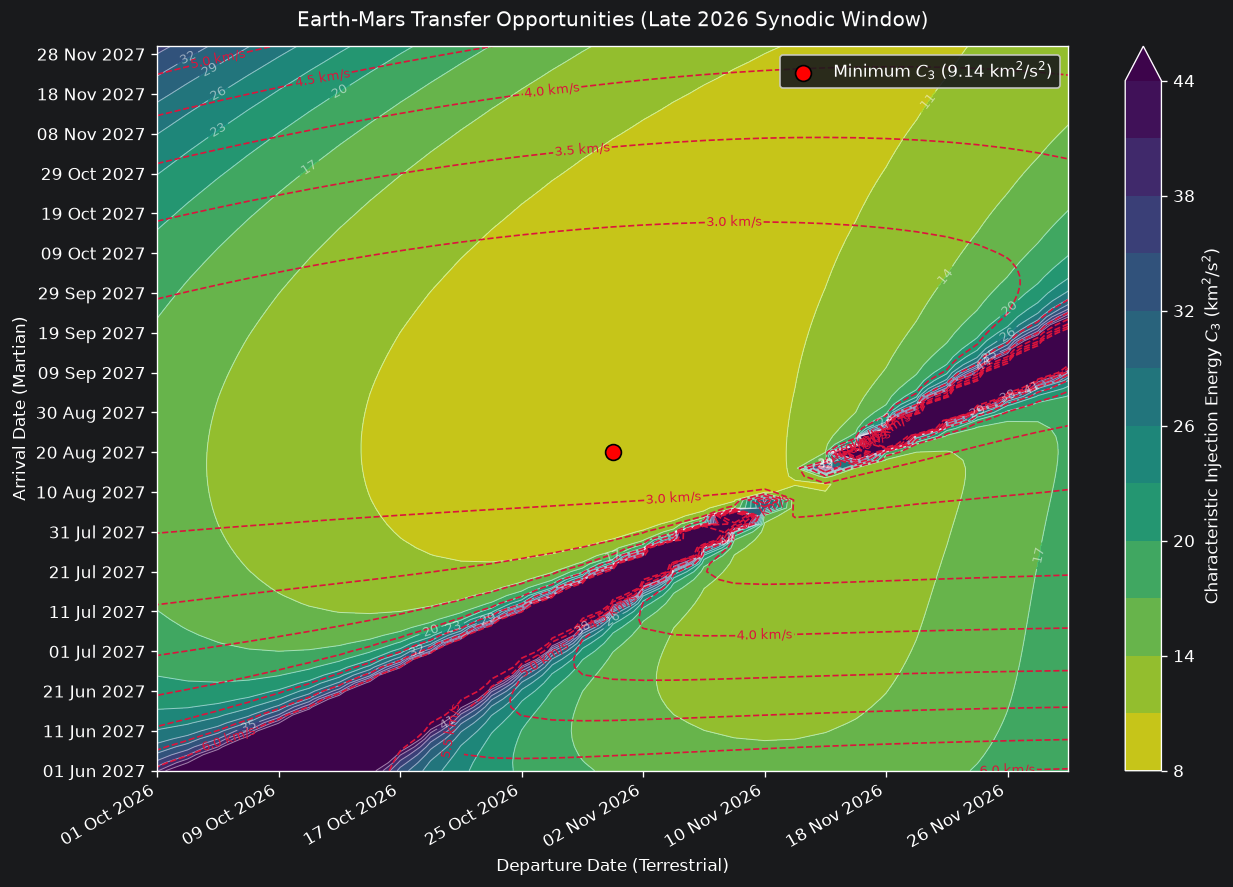

In [25]:
fig, ax = plt.subplots(figsize=(11, 7.5), dpi=120)

dep_ordinals = [d.toordinal() for d in departure_dates]
arr_ordinals = [d.toordinal() for d in arrival_dates]
X, Y = np.meshgrid(dep_ordinals, arr_ordinals)

# Render characteristic energy contours
c3_levels = np.arange(8.0, 46.0, 3.0)
c3_filled = ax.contourf(X, Y, c3_matrix, levels=c3_levels, cmap="viridis_r", extend="max", alpha=0.85)
c3_lines = ax.contour(X, Y, c3_matrix, levels=c3_levels, colors="white", linewidths=0.6, alpha=0.5)
ax.clabel(c3_lines, inline=True, fmt="%.0f", fontsize=8)

# Overlay hyperbolic arrival speed contours
vinf_levels = np.arange(2.0, 6.5, 0.5)
vinf_lines = ax.contour(X, Y, vinf_arr_matrix, levels=vinf_levels, colors="crimson", linestyles="--", linewidths=1.0)
ax.clabel(vinf_lines, inline=True, fmt="%.1f km/s", fontsize=8)

# Designate optimal trajectory coordinate
ax.scatter(
    [optimal_dep_date.toordinal()],
    [optimal_arr_date.toordinal()],
    color="red",
    s=90,
    edgecolors="black",
    zorder=5,
    label=f"Minimum $C_3$ ({optimal_c3:.2f} $\\mathrm{{km}}^2/\\mathrm{{s}}^2$)"
)

# Configure temporal axes
tick_step_dep = 4
tick_step_arr = 5
ax.set_xticks(dep_ordinals[::tick_step_dep])
ax.set_xticklabels([departure_dates[i].strftime("%d %b %Y") for i in range(0, len(departure_dates), tick_step_dep)], rotation=30, ha="right")
ax.set_yticks(arr_ordinals[::tick_step_arr])
ax.set_yticklabels([arrival_dates[i].strftime("%d %b %Y") for i in range(0, len(arrival_dates), tick_step_arr)])

ax.set_title("Earth-Mars Transfer Opportunities (Late 2026 Synodic Window)", fontsize=12, pad=12)
ax.set_xlabel("Departure Date (Terrestrial)", fontsize=10)
ax.set_ylabel("Arrival Date (Martian)", fontsize=10)
ax.legend(loc="upper right", framealpha=0.9)

cbar = fig.colorbar(c3_filled, ax=ax)
cbar.set_label("Characteristic Injection Energy $C_3$ ($\\mathrm{km}^2 / \\mathrm{s}^2$)", fontsize=10)

plt.tight_layout()
plt.show()

---

## 4. Launch Vehicle Sizing & Payload Mass Analysis

The practical feasibility of an interplanetary mission depends on the launch system's ability to supply the requisite injection energy $C_3$.

Utilising the empirical polynomial representations encapsulated within `LaunchVehicle.payload_for_c3(c3)` across the catalogued configurations, we determine the net spacecraft mass deliverable to the trans-Mars trajectory:

$$m_{\text{spacecraft}} \le f_{\text{vehicle}}(C_3)$$

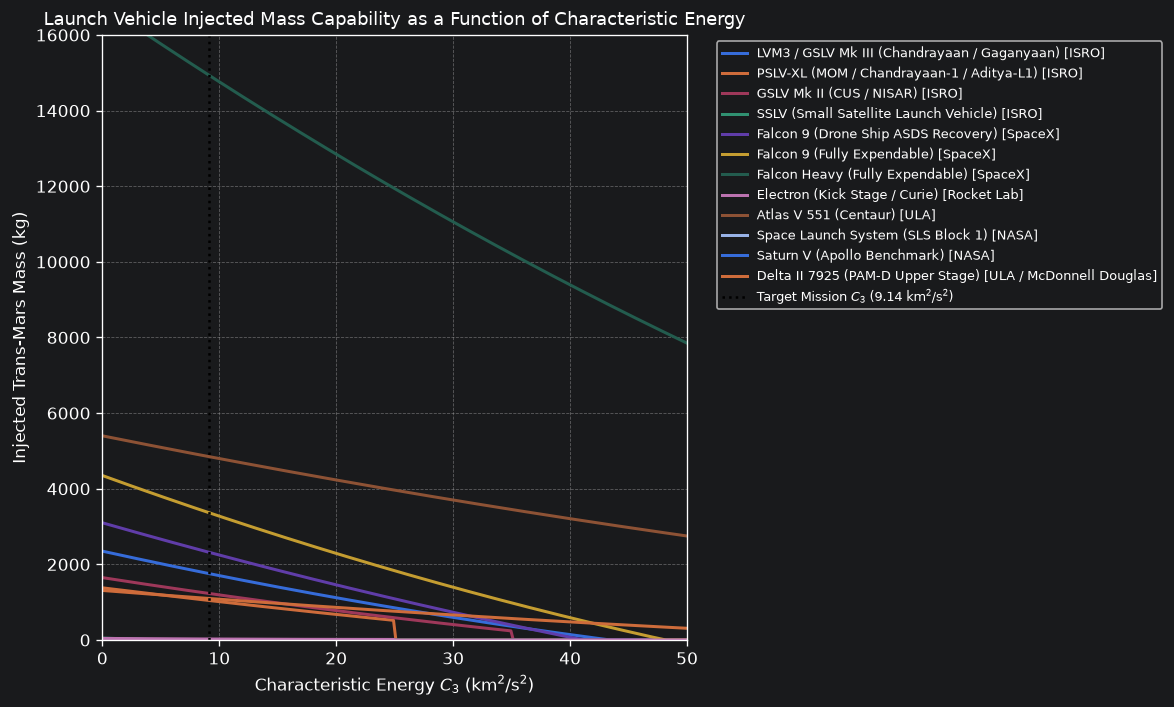

Quantified Injected Spacecraft Capacity at Optimal C_3 (9.14 km²/s²):
  * LVM3 / GSLV Mk III (Chandrayaan / Gaganyaan)           : 1,755.1 kg
  * PSLV-XL (MOM / Chandrayaan-1 / Aditya-L1)              : 1,044.3 kg
  * GSLV Mk II (CUS / NISAR)                               : 1,229.6 kg
  * SSLV (Small Satellite Launch Vehicle)                  : Infeasible (C_3 limit exceeded)
  * Falcon 9 (Drone Ship ASDS Recovery)                    : 2,317.6 kg
  * Falcon 9 (Fully Expendable)                            : 3,363.7 kg
  * Falcon Heavy (Fully Expendable)                        : 14,931.9 kg
  * Electron (Kick Stage / Curie)                          : 26.1 kg
  * Atlas V 551 (Centaur)                                  : 4,848.2 kg
  * Space Launch System (SLS Block 1)                      : 27,962.6 kg
  * Saturn V (Apollo Benchmark)                            : 46,432.0 kg
  * Delta II 7925 (PAM-D Upper Stage)                      : 1,097.3 kg


In [26]:
c3_evaluation_domain = np.linspace(0.0, 50.0, 250)
launcher_catalogue = list_available_launchers()

plt.figure(figsize=(10, 6), dpi=120)

# Evaluate injected mass profiles
for metadata in launcher_catalogue:
    key = metadata['key']
    operator = metadata['operator']
    disp_name = metadata['name']

    try:
        vehicle = get_launcher(key)
        capacities = [
            vehicle.payload_for_c3(c) if c <= vehicle.max_c3_km2_s2 else 0.0
            for c in c3_evaluation_domain
        ]
        plt.plot(c3_evaluation_domain, capacities, label=f"{disp_name} [{operator}]", lw=1.8)
    except (KeyError, AttributeError):
        continue

plt.axvline(
    optimal_c3,
    color="black",
    linestyle=":",
    lw=1.5,
    label=f"Target Mission $C_3$ ({optimal_c3:.2f} $\\mathrm{{km}}^2/\\mathrm{{s}}^2$)"
)

plt.title("Launch Vehicle Injected Mass Capability as a Function of Characteristic Energy", fontsize=11)
plt.xlabel("Characteristic Energy $C_3$ ($\\mathrm{km}^2 / \\mathrm{s}^2$)", fontsize=10)
plt.ylabel("Injected Trans-Mars Mass (kg)", fontsize=10)
plt.xlim(0.0, 50.0)
plt.ylim(0.0, 16000.0)
plt.grid(True, linestyle="--", alpha=0.45)
plt.legend(frameon=True, fontsize=7.5, bbox_to_anchor=(1.04, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Quantified Injected Spacecraft Capacity at Optimal C_3 ({optimal_c3:.2f} km²/s²):")
for metadata in launcher_catalogue:
    key = metadata['key']
    disp_name = metadata['name']
    try:
        vehicle = get_launcher(key)
        payload_mass = vehicle.payload_for_c3(optimal_c3)
        status_descriptor = f"{payload_mass:,.1f} kg" if payload_mass > 0 else "Infeasible (C_3 limit exceeded)"
        print(f"  * {disp_name:<55}: {status_descriptor}")
    except (KeyError, AttributeError):
        pass

---

## 5. Numerical Trajectory Propagation & Intercept Validation

To validate the boundary-value solution, the heliocentric equation of motion:

$$\ddot{\mathbf{r}} = -\frac{\mu_{\odot}}{\|\mathbf{r}\|^3}\mathbf{r}$$

is integrated across the nominal time-of-flight $\Delta t$ using the initial state vector $\mathbf{y}_0 = [\mathbf{r}_1^T, \mathbf{v}_{1,\text{trans}}^T]^T$. Numerical integration is conducted via the Dormand-Prince adaptive 5(4) Runge-Kutta algorithm (`rk45_adaptive`) with absolute and relative error tolerances set to $10^{-12}$ and $10^{-10}$ respectively.

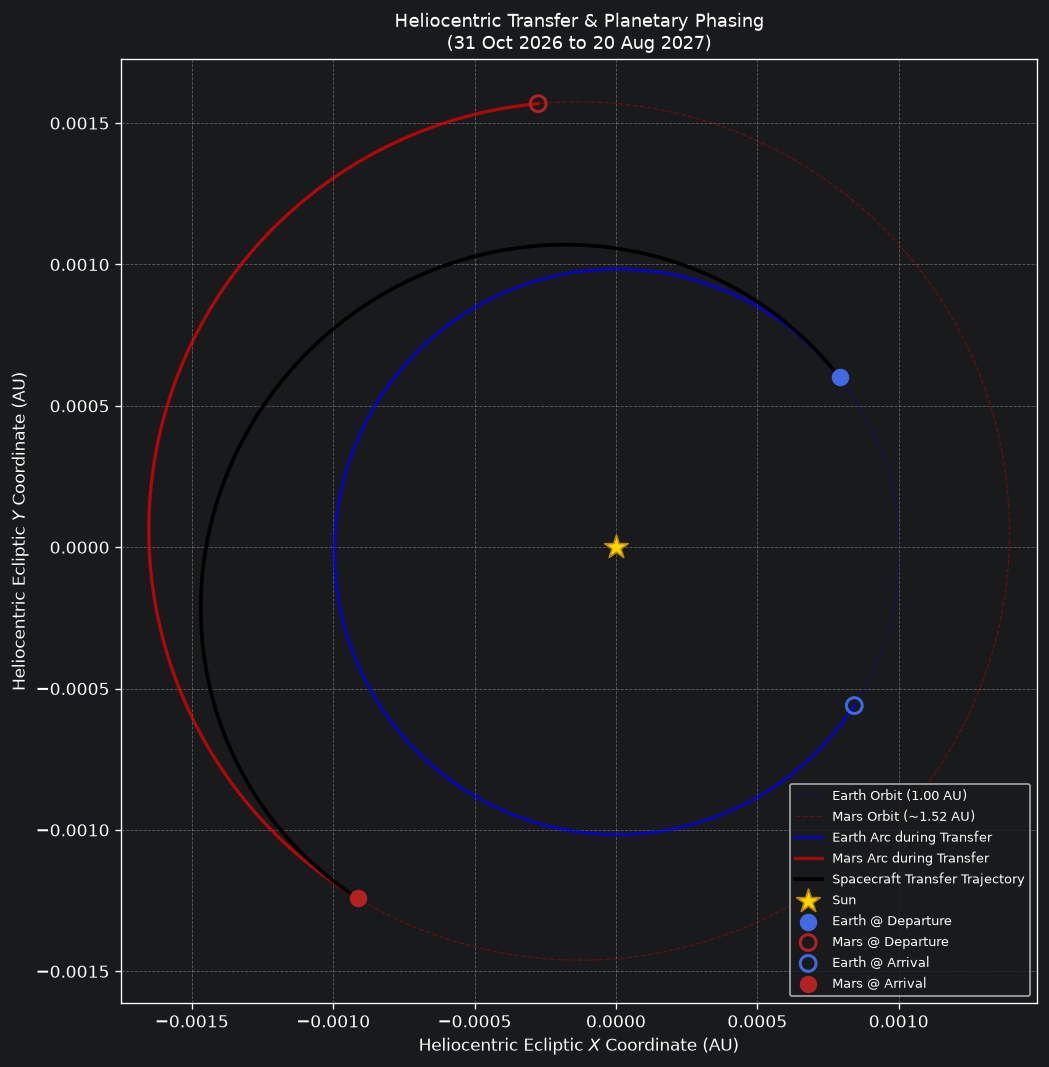

In [27]:
# Resolve boundary state vectors
mjd_dep_opt = date_to_mjd2000(optimal_dep_date)
mjd_arr_opt = date_to_mjd2000(optimal_arr_date)

r1_boundary, v_earth_dep = get_planet_state("Earth", mjd_dep_opt)
r2_boundary, v_mars_arr  = get_planet_state("Mars", mjd_arr_opt)
tof_seconds = optimal_tof_days * SECS_PER_DAY

# Resolve off-epoch states
r_earth_arr, _ = get_planet_state("Earth", mjd_arr_opt)
r_mars_dep, _  = get_planet_state("Mars", mjd_dep_opt)

# Resolve departure velocity vector
v1_opt_trans, _ = solve_lambert(r1_boundary, r2_boundary, tof_seconds, mu=MU_SUN, prograde=True)

# Point-mass acceleration field for spacecraft
def heliocentric_point_mass_derivative(t: float, state: np.ndarray) -> np.ndarray:
    pos = state[:3]
    vel = state[3:]
    r = np.linalg.norm(pos)
    return np.concatenate([vel, -MU_SUN / (r**3) * pos])

# Execute Dormand-Prince adaptive numerical integration for spacecraft
initial_state = np.concatenate([r1_boundary, v1_opt_trans])
t_grid, state_grid = rk45_adaptive(
    heliocentric_point_mass_derivative,
    t_span=(0.0, tof_seconds),
    y0=initial_state,
    rtol=1e-10,
    atol=1e-12
)

# Compute terminal miss distance for downstream reporting
final_position = state_grid[-1, :3]
targeting_miss_distance = float(np.linalg.norm(final_position - r2_boundary))

# Sample actual planet positions over the full year to trace their genuine eccentric orbits
earth_orbit_pts = np.array([get_planet_state("Earth", mjd_dep_opt + d)[0] for d in np.linspace(0, 365.25, 300)])
mars_orbit_pts  = np.array([get_planet_state("Mars",  mjd_dep_opt + d)[0] for d in np.linspace(0, 686.98, 400)])

# Sample planet arcs specifically during the transfer window (departure -> arrival)
window_days = np.linspace(0, optimal_tof_days, 150)
earth_window_arc = np.array([get_planet_state("Earth", mjd_dep_opt + d)[0] for d in window_days])
mars_window_arc  = np.array([get_planet_state("Mars",  mjd_dep_opt + d)[0] for d in window_days])

# Visualise
plt.figure(figsize=(9, 9), dpi=120)

# Full planet orbit ellipses (exact ephemeris traces)
plt.plot(earth_orbit_pts[:, 0] / AU, earth_orbit_pts[:, 1] / AU, 'b--', lw=0.8, alpha=0.3, label="Earth Orbit (1.00 AU)")
plt.plot(mars_orbit_pts[:, 0] / AU,  mars_orbit_pts[:, 1] / AU,  'r--', lw=0.8, alpha=0.3, label="Mars Orbit (~1.52 AU)")

# Planetary movement arcs swept DURING the transfer window
plt.plot(earth_window_arc[:, 0] / AU, earth_window_arc[:, 1] / AU, 'b-', lw=2.0, alpha=0.6, label="Earth Arc during Transfer")
plt.plot(mars_window_arc[:, 0] / AU,  mars_window_arc[:, 1] / AU,  'r-', lw=2.0, alpha=0.6, label="Mars Arc during Transfer")

# Spacecraft transfer trajectory
plt.plot(state_grid[:, 0] / AU, state_grid[:, 1] / AU, 'k-', lw=2.2, label="Spacecraft Transfer Trajectory")

# Sun
plt.scatter([0], [0], color="gold", s=220, marker="*", edgecolors="darkgoldenrod", zorder=6, label="Sun")

# Departure states (t = 0)
plt.scatter([r1_boundary[0] / AU], [r1_boundary[1] / AU], color="royalblue", s=90, zorder=5, label="Earth @ Departure")
plt.scatter([r_mars_dep[0] / AU],  [r_mars_dep[1] / AU],  color="none", edgecolors="firebrick", lw=1.8, s=90, zorder=5, label="Mars @ Departure")

# Arrival states (t = TOF)
plt.scatter([r_earth_arr[0] / AU], [r_earth_arr[1] / AU], color="none", edgecolors="royalblue", lw=1.8, s=90, zorder=5, label="Earth @ Arrival")
plt.scatter([r2_boundary[0] / AU], [r2_boundary[1] / AU], color="firebrick", s=90, zorder=5, label="Mars @ Arrival")

plt.title(f"Heliocentric Transfer & Planetary Phasing\n({optimal_dep_date.strftime('%d %b %Y')} to {optimal_arr_date.strftime('%d %b %Y')})", fontsize=11)
plt.xlabel("Heliocentric Ecliptic $X$ Coordinate (AU)", fontsize=10)
plt.ylabel("Heliocentric Ecliptic $Y$ Coordinate (AU)", fontsize=10)
plt.axis("equal")
plt.grid(True, linestyle="--", alpha=0.45)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

---

## 6. Mission Architecture Synthesis & Trajectory Summary

Below is the consolidated mission design summary for the optimal ballistic transfer opportunity, synthesising the kinematic parameters, launch vehicle capabilities, and targeting metrics evaluated across the pipeline.

In [28]:
# Key operational metrics
print("==================================================================================")
print("             NEWTONIAN PROPAGATOR - INTERPLANETARY MISSION REPORT                 ")
print("                     Earth-to-Mars Trajectory Baseline                            ")
print("==================================================================================")
print(f"Target Destination                   : Mars")
print(f"Departure Body                       : Earth")
print(f"Optimal Departure Epoch              : {optimal_dep_date.strftime('%d %B %Y')} (MJD2000: {mjd_dep_opt:.2f})")
print(f"Optimal Arrival Epoch                : {optimal_arr_date.strftime('%d %B %Y')} (MJD2000: {mjd_arr_opt:.2f})")
print(f"Total Time of Flight (TOF)           : {optimal_tof_days} days ({optimal_tof_days / 30.4375:.1f} months)")
print("----------------------------------------------------------------------------------")
print("KINEMATIC & ENERGY PARAMETERS")
print(f"Characteristic Energy (C3)           : {optimal_c3:.3f} km²/s²")
print(f"Departure Injection Excess Speed     : {np.sqrt(optimal_c3):.3f} km/s")
print(f"Arrival Hyperbolic Excess Speed (v∞) : {optimal_vinf_arr:.3f} km/s")
print(f"Earth Orbital Radius at Departure    : {np.linalg.norm(r1_boundary) / AU:.4f} AU")
print(f"Mars Orbital Radius at Arrival       : {np.linalg.norm(r2_boundary) / AU:.4f} AU")
print("----------------------------------------------------------------------------------")
print("NUMERICAL INTEGRATION & TARGETING ACCURACY")
print(f"Propagation Scheme                   : Dormand-Prince 5(4) Adaptive Runge-Kutta")
print(f"Adaptive Step Count                  : {len(t_grid)} steps")
print(f"Terminal Position Intercept Error    : {targeting_miss_distance:.4e} km")
print("----------------------------------------------------------------------------------")
print("LAUNCH VEHICLE DELIVERABLE MASS CAPACITIES (AT OPTIMAL C3)")
for metadata in launcher_catalogue:
    key = metadata['key']
    disp_name = metadata['name']
    operator = metadata['operator']
    try:
        vehicle = get_launcher(key)
        payload_mass = vehicle.payload_for_c3(optimal_c3)
        if payload_mass > 0:
            print(f"  * {disp_name:<48} [{operator:<7}] : {payload_mass:>9,.0f} kg")
        else:
            print(f"  * {disp_name:<48} [{operator:<7}] : Infeasible (exceeds C3)")
    except (KeyError, AttributeError):
        pass
print("==================================================================================")

             NEWTONIAN PROPAGATOR - INTERPLANETARY MISSION REPORT                 
                     Earth-to-Mars Trajectory Baseline                            
Target Destination                   : Mars
Departure Body                       : Earth
Optimal Departure Epoch              : 31 October 2026 (MJD2000: 9799.50)
Optimal Arrival Epoch                : 20 August 2027 (MJD2000: 10092.50)
Total Time of Flight (TOF)           : 293 days (9.6 months)
----------------------------------------------------------------------------------
KINEMATIC & ENERGY PARAMETERS
Characteristic Energy (C3)           : 9.142 km²/s²
Departure Injection Excess Speed     : 3.024 km/s
Arrival Hyperbolic Excess Speed (v∞) : 2.713 km/s
Earth Orbital Radius at Departure    : 0.0010 AU
Mars Orbital Radius at Arrival       : 0.0015 AU
----------------------------------------------------------------------------------
NUMERICAL INTEGRATION & TARGETING ACCURACY
Propagation Scheme                   : Dormand-